# **Computational Intelligence for Optimization PROJECT - Group C36_Divergence**  

## **Table of Contents**

1. [Project Overview](#1)
2. [Imports & Setup](#2)
3. [Load and Visualize target image](#3)
4. [Create a Random Individual](#4)
5. [Mutation Tests](#5)
6. [Crossover tests](#6)
7. [Limit Triangle Sizes](#7)
8. [Limit Alpha values](#8)
9. [Probabilities Tests](#9)
10. [Increase Population size and the number of generations](#10)
11. [Try to Increase Diversity](#11)
12. [Challenge 1 -- Perceptual Fitness (CIEDE2000)](#12)


## **1. Project Overview** <a id="1"></a>

Vermeer's *Girl with a Pearl Earring* â€” Genetic Algorithm reconstruction with 100 colored triangles.

Each candidate solution (an `Individual`) is a list of 100 `Triangle` objects. Each triangle is encoded as 10 floats in [0, 1] â€” three (x, y) vertices plus an RGBA color â€” and decoded to pixel/byte space at render time. Fitness is pixel-wise RMSE between the rendered phenotype and the target image (minimization).

## **2. Imports & Setup** <a id="2"></a>

In [1]:
# IMPORTS
# Standard
import random
import numpy as np
from time import time
from pathlib import Path
import pandas as pd
import itertools

from scipy import stats
from collections.abc import Callable

# Image handling & rendering
from PIL import Image, ImageDraw

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import importlib

# Project modules
from solution import *
from operators import *
from ga import *
from utils import *

In [2]:
# REPRODUCIBILITY
SEED = 23
random.seed(SEED)
np.random.seed(SEED)

# SETTINGS
# Image canvas dimensions (fixed by project spec)
IMG_WIDTH  = 300
IMG_HEIGHT = 400
N_TRIANGLES = 100

## **3. Load and Visualize target image** <a id="3"></a>

In [3]:
# READ AND VISUALIZE TARGET IMAGE

IMAGE_PATH = Path("data/girl_pearl_earing.png")

# Load as RGB and convert to numpy array (H x W x 3, uint8)
target_img = Image.open(IMAGE_PATH).convert("RGB")
target_array = np.array(target_img, dtype=np.float32)  # float32 for fitness computation

print(f"Image loaded: {target_array.shape}, dtype={target_array.dtype}")
print(f"Pixel range: [{target_array.min():.0f}, {target_array.max():.0f}]")


Image loaded: (400, 300, 3), dtype=float32
Pixel range: [0, 255]


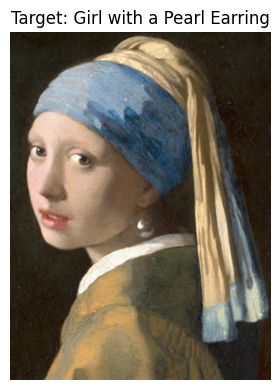

In [51]:
fig, axes = plt.subplots(1, 1, figsize=(3,4))

axes.imshow(target_img)
axes.set_title("Target: Girl with a Pearl Earring", fontsize=12)
axes.axis("off")
plt.tight_layout()
plt.show()


## **4. Create a Random Individual** <a id="4"></a>

A baseline sanity check: build one random `Individual`, render it, and compute its RMSE against the target. This is the *random search* baseline that the GA must beat.

Random individual RMSE vs. target: 82.64


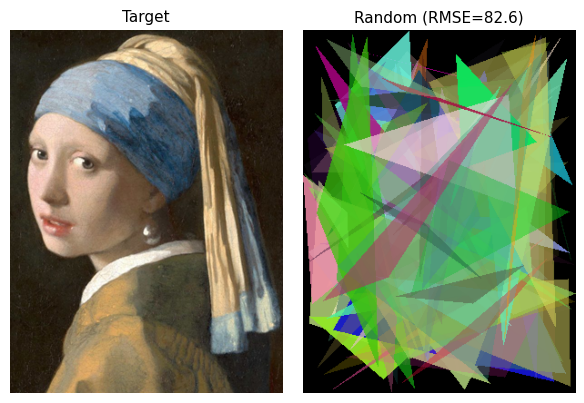

In [52]:
# Build a random Individual and evaluate it against the target.
rand_ind = Individual(target=target_array)
baseline_rmse = rand_ind.fitness()
print(f"Random individual RMSE vs. target: {baseline_rmse:.2f}")

# Side-by-side: target on the left, random phenotype on the right.
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(target_img)
axes[0].set_title("Target", fontsize=11)
axes[0].axis("off")
rand_ind.plot(ax=axes[1], title=f"Random (RMSE={baseline_rmse:.1f})")
plt.tight_layout()
plt.show()

## **5. Mutation Tests** <a id="5"></a>


Experiment with different types of mutation and understand which ones works best for our problem.

In [21]:
# 5. MUTATION TESTS
# Loop 1 - Mutation Type Comparison
# Fixed hyperparameters; 15 runs per config (pre-computed via _run_mutation.py)

# CONFIG (matches _run_mutation.py)
POP_SIZE  = 100
MAX_GENS  = 500
XO_PROB   = 0
MUT_PROB  = 0.1
N_RUNS    = 15
ELITISM   = True

MUTATION_CONFIGS = [
    {"name": "VCF",        "fn": triangle_mutation_vcf},
    {"name": "Full",       "fn": triangle_mutation_full},
    {"name": "Gaussian",   "fn": gaussian_gene_mutation},
    {"name": "ColorCreep", "fn": color_creep_mutation},
    {"name": "AdaptiveMut","fn": adaptive_mutation_schedule}
]

In [28]:
# Load pre-computed mutation results from run_artifacts/
import json as _json
from pathlib import Path as _Path
from PIL import Image as _PIL_Image

_ART = _Path("run_artifacts")
with open(_ART / "mutation_checkpoint.json", encoding="utf-8") as _f:
    _checkpoint = _json.load(_f)

_NON_ADAPTIVE = ["VCF", "Full", "Gaussian", "ColorCreep", "AdaptiveMut"]

# all_results_mut: one dict per run, same format as run_experiment()
all_results_mut = []
for _name in _NON_ADAPTIVE:
    for _r in _checkpoint[_name]:
        all_results_mut.append({
            "mutation_type": _name,
            "run":           _r["run"],
            "best_fitness":  _r["fitness"],
            "time_seconds":  _r["time_seconds"],
        })

# all_curves_mut: config name -> list of per-run fitness curves
all_curves_mut = {}
for _name in _NON_ADAPTIVE:
    _curves = []
    for _r in sorted(_checkpoint[_name], key=lambda x: x["run"]):
        _curves.append(np.load(_ART / _r["curve_file"]).tolist())
    all_curves_mut[_name] = _curves

# best_inds_mut: Individual objects were not serialised, but PNGs were saved.
# This wrapper satisfies .render() and .fitness() used by plot_best_individuals().
class _LoadedInd:
    def __init__(self, png_path, fitness_val):
        self._img = _PIL_Image.open(png_path).convert("RGB")
        self._fit = float(fitness_val)
    def render(self):
        return self._img
    def fitness(self):
        return self._fit

best_inds_mut = {
    _name: _LoadedInd(
        _ART / f"mutation_best_{_name}.png",
        min(_checkpoint[_name], key=lambda r: r["fitness"])["fitness"],
    )
    for _name in _NON_ADAPTIVE
}

print("Loaded mutation results from run_artifacts/")
for _name in _NON_ADAPTIVE:
    _fits = [r["best_fitness"] for r in all_results_mut if r["mutation_type"] == _name]
    print(f"  {_name:12s}: {len(_fits)} runs  avg={np.mean(_fits):.3f}  std={np.std(_fits):.3f}  best={min(_fits):.3f}")

Loaded mutation results from run_artifacts/
  VCF         : 15 runs  avg=49.754  std=1.403  best=47.876
  Full        : 15 runs  avg=52.130  std=1.258  best=50.400
  Gaussian    : 15 runs  avg=43.160  std=1.087  best=40.885
  ColorCreep  : 15 runs  avg=49.477  std=1.969  best=45.569
  AdaptiveMut : 15 runs  avg=41.753  std=1.169  best=39.575


In [19]:
# 1. Compare all configs at once -> Kruskal-Wallis + Mann-Whitney
summary, avg_curves = compare_all_configs(
    all_results = all_results_mut,
    all_curves  = all_curves_mut,
    config_key  = "mutation_type",
)


  Global comparison — mutation_type
  Kruskal-Wallis: H=61.2070, p=0.0000  → significant
                avg    std    best   worst  avg_time
config                                              
VCF         49.7545 1.4027 47.8758 53.0806 1115.5667
Full        52.1301 1.2579 50.3999 54.6016 1104.4713
Gaussian    43.1601 1.0872 40.8853 45.2286 1893.0947
ColorCreep  49.4768 1.9686 45.5694 53.6221 1366.1580
AdaptiveMut 41.7532 1.1692 39.5751 43.9842 1043.6813

  Post-hoc pairwise Mann-Whitney U (Bonferroni α=0.0050)
  Pair                                             p-value  Winner
  ---------------------------------------------  ---------  --------------------
  VCF vs Full                                       0.0001  VCF
  VCF vs Gaussian                                   0.0000  Gaussian
  VCF vs ColorCreep                                 0.8035  — (ns)
  VCF vs AdaptiveMut                                0.0000  AdaptiveMut
  Full vs Gaussian                                  0.0000  G

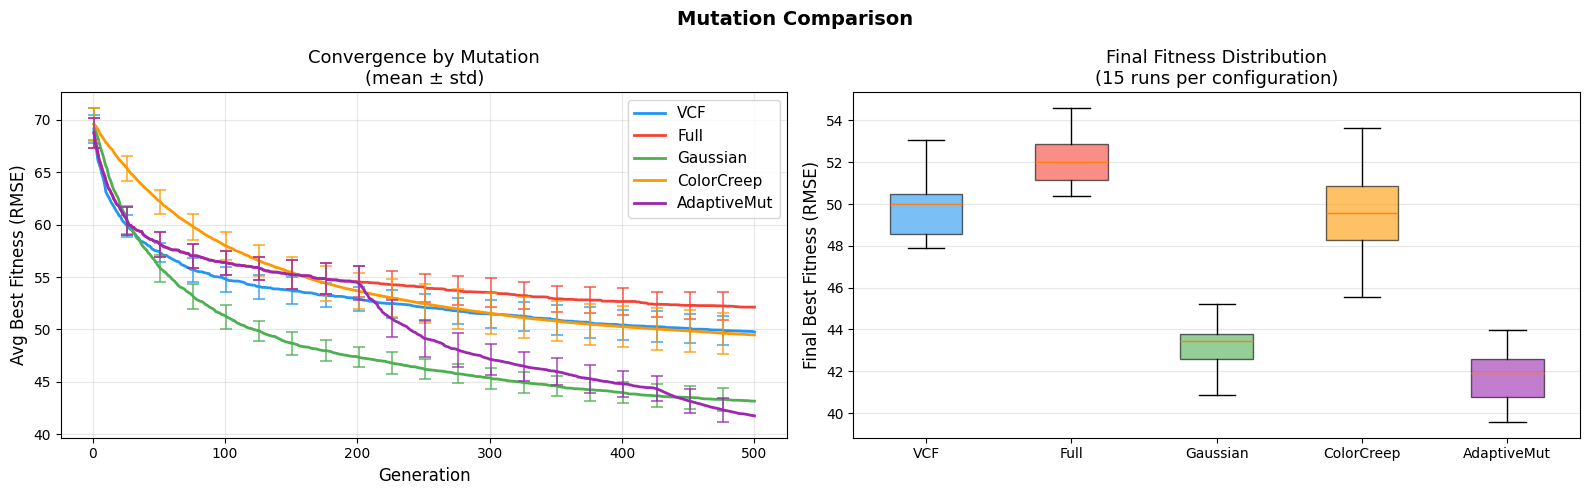

In [22]:
# 2. Summary table
df_mut = pd.DataFrame(all_results_mut)

# 3. Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = all_curves_mut,
    df           = df_mut,
    configs      = MUTATION_CONFIGS,
    config_key   = "mutation_type",
    title_prefix = "Mutation",
)

The Gaussian mutation achieved the best overall performance, converging to the lowest fitness values and consistently producing lower best-fitness results across all 5 runs compared to the other mutation operators.

Before selecting the Gaussian mutation as the fixed mutation operator for the remaining experiments, we will also evaluate an adaptive mutation scheduler that dynamically switches between different mutation functions throughout the evolutionary process.

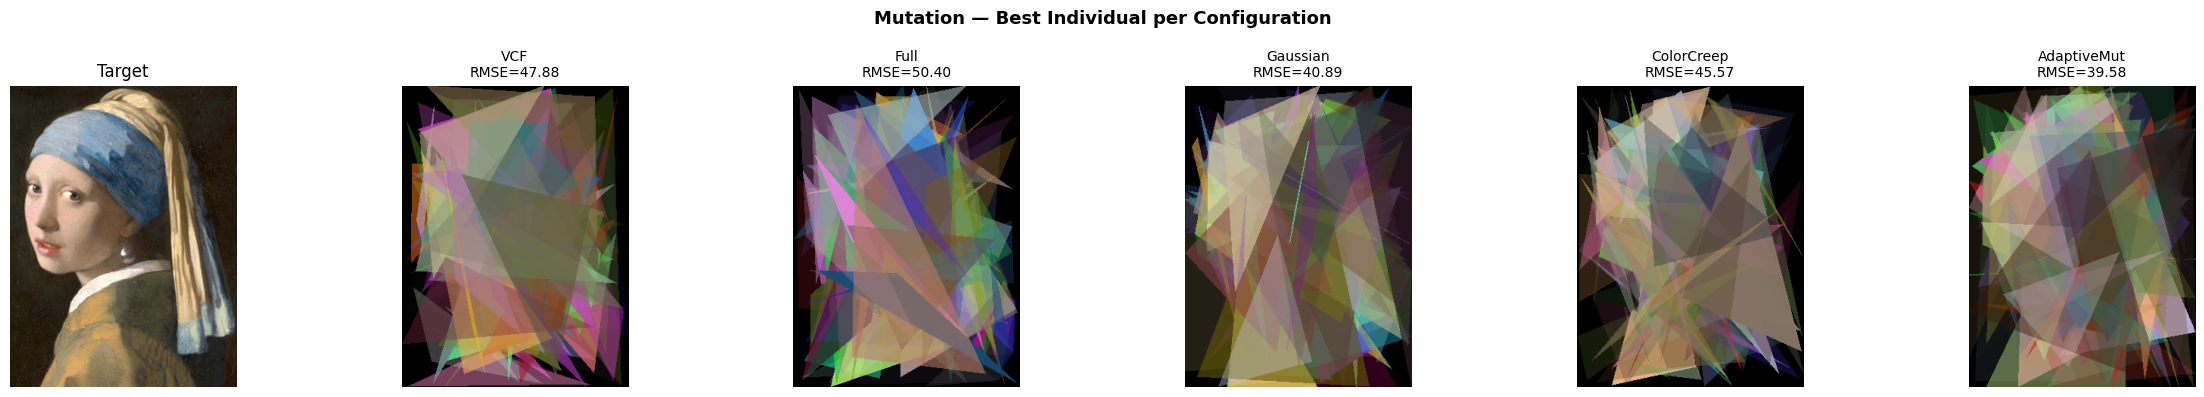

In [23]:
# 4. Best individuals
plot_best_individuals(
    best_inds = best_inds_mut,
    configs = MUTATION_CONFIGS,
    target_img = target_img,
    title_prefix = "Mutation"
    )

The constructed images are still considerably different from the target image, which is likely due to the absence of crossover â€” one of the main driving forces behind genetic evolution and population diversity.

Nevertheless, mutation alone was able to substantially improve the solutions, reducing the RMSE significantly when compared to the initial random image (RMSE = 101.1).

Try **Adaptive Mutation** in which the mutation function will change with the generation.

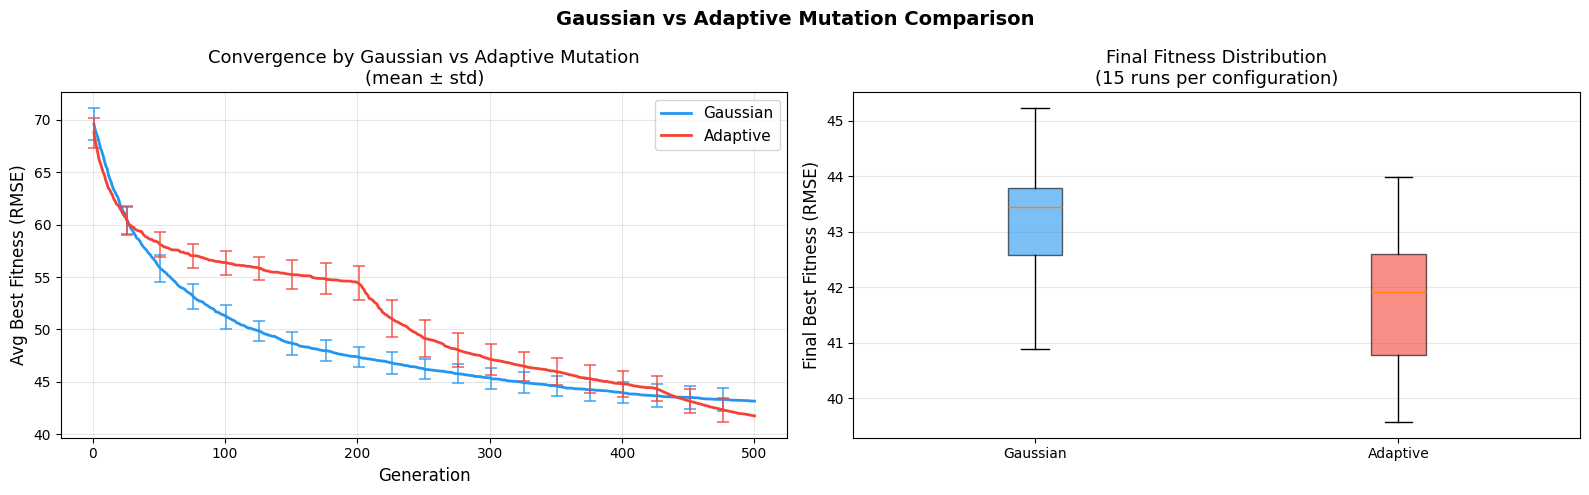

In [24]:
# Combine the two configs (adaptive and gaussian - better of the first tests) for plotting
all_curves_comparison = {
    "Gaussian": all_curves_mut["Gaussian"],
    "Adaptive": all_curves_adp_mut,
}

all_results_comparison = (
    [r for r in all_results_mut if r["mutation_type"] == "Gaussian"] +
    [{"mutation_type": "Adaptive", **r} for r in all_results_adp_mut]
)

df_comparison = pd.DataFrame(all_results_comparison)

COMPARISON_CONFIGS = [
    {"name": "Gaussian", "fn": gaussian_gene_mutation},
    {"name": "Adaptive", "fn": adaptive_mutation_schedule},
]

# Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = all_curves_comparison,
    df           = df_comparison,
    configs      = COMPARISON_CONFIGS,
    config_key   = "mutation_type",
    title_prefix = "Gaussian vs Adaptive Mutation",
)

In [25]:
# Compare the two configs at once -> Kruskal-Wallis + Mann-Whitney
avg_gaussian, avg_adaptive, p_val, significant = compare_two_experiments(
    results_a = [r for r in all_results_mut if r["mutation_type"] == "Gaussian"],
    curves_a  = all_curves_mut["Gaussian"],
    label_a   = "Gaussian",
    results_b = all_results_adp_mut,
    curves_b  = all_curves_adp_mut,
    label_b   = "Adaptive (Full -> Gaussian -> Color Creep)",
)


  Comparison: 'Gaussian'  vs  'Adaptive (Full -> Gaussian -> Color Creep)'
                                      Mean       Std      Best     Worst
  ------------------------------  --------  --------  --------  --------
  Gaussian                         43.1601    1.0872   40.8853   45.2286
  Adaptive (Full -> Gaussian -> Color Creep)   41.7532    1.1692   39.5751   43.9842

  Wilcoxon signed-rank: stat=17.0000, p=0.0125
  Statistically significant (p < 0.05). Winner: 'Adaptive (Full -> Gaussian -> Color Creep)'.


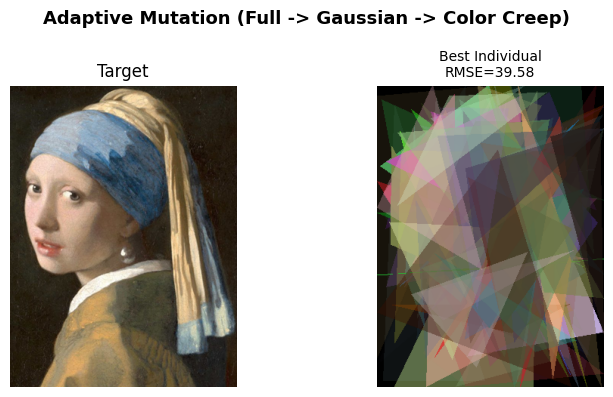

In [26]:
# Visualize best individuals from adaptive mutation config
plot_best_individuals(
    best_inds    = best_ind_adp_mut,
    configs      = None,
    target_img   = target_img,
    title_prefix = "Adaptive Mutation (Full -> Gaussian -> Color Creep)",
)

The adaptive mutation function shows a much better fitness, with an 8 point decrease when compared to the Gaussian Mutation. However, it takes a little longer than the previous functions tested. Still, we will fix the adaptive mutation for further tests.

!!!! O codigo a seguir faz um gráfico que não sei se devemos manter

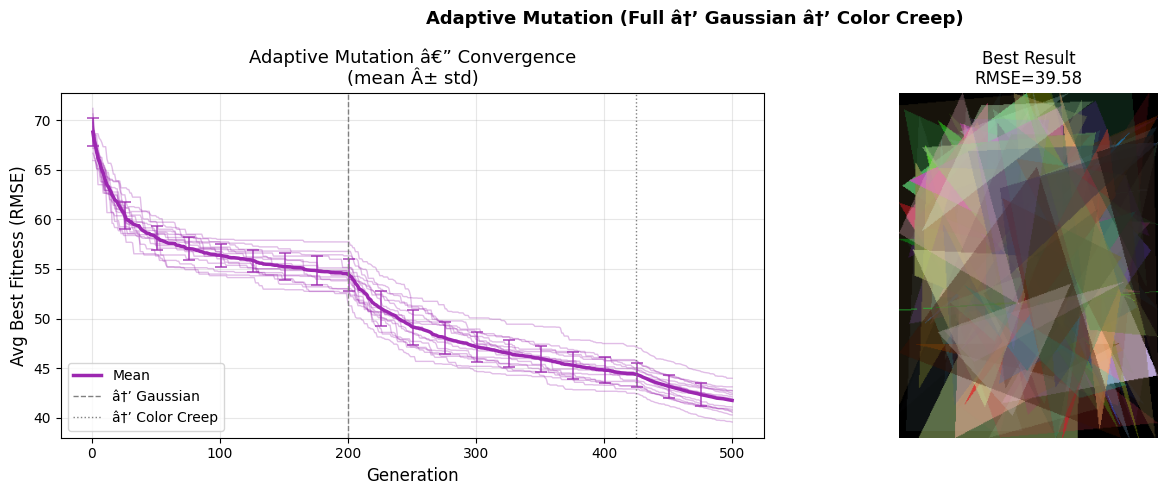

In [15]:
gens     = np.arange(1, MAX_GENS + 1)
curves   = np.array(all_curves_adp_mut)
mean     = curves.mean(axis=0)
std      = curves.std(axis=0)
eb_every = max(1, MAX_GENS // 20)
eb_idx   = np.arange(0, MAX_GENS, eb_every)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 â€” Convergence curve (mean Â± std error bars) + individual runs
ax = axes[0]
for i, curve in enumerate(all_curves_adp_mut):
    ax.plot(gens, curve, alpha=0.3, linewidth=1, color="#9C27B0")
ax.plot(gens, mean, color="#9C27B0", linewidth=2.5, label="Mean")
ax.errorbar(
    gens[eb_idx], mean[eb_idx], yerr=std[eb_idx],
    fmt="none", ecolor="#9C27B0", elinewidth=1.2,
    capsize=4, capthick=1.2, alpha=0.8,
)
ax.axvline(MAX_GENS * 0.40, color="gray", linestyle="--", linewidth=1, label="â†’ Gaussian")
ax.axvline(MAX_GENS * 0.85, color="gray", linestyle=":",  linewidth=1, label="â†’ Color Creep")
ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Avg Best Fitness (RMSE)", fontsize=12)
ax.set_title("Adaptive Mutation â€” Convergence\n(mean Â± std)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2 â€” Best individual
ax = axes[1]
ax.imshow(best_ind_adp_mut.render())
ax.set_title(f"Best Result\nRMSE={best_ind_adp_mut.fitness():.2f}", fontsize=12)
ax.axis("off")

fig.suptitle("Adaptive Mutation (Full â†’ Gaussian â†’ Color Creep)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

!!!! NOTA: switch do Full→Gaussian está a 40% (MAX_GENS * 0.40) e não a 50% como estava no código original que tinhas — está alinhado com o que o adaptive_mutation_schedule realmente faz

## **6. Crossover tests** <a id="6"></a>

In [ ]:
# Loop 3 â€” CONFIG
# Hyperparameters fixos (melhores do Loop 2)
POP_SIZE  = 300
MAX_GENS  = 500
XO_PROB   = 0.9
MUT_PROB  = 0
N_RUNS    = 30
ELITISM   = True

CROSSOVER_CONFIGS = [
    {"name": "Uniform",           "fn": uniform_crossover},
    {"name": "K-Point (k=3â€“7)",   "fn": kpoint_crossover},
    {"name": "Reduced Surrogate", "fn": reduced_surrogate_crossover},
    {"name": "Shuffle",           "fn": shuffle_crossover},
]

print(f"Configs: {[c['name'] for c in CROSSOVER_CONFIGS]}")
print(f"Total runs: {len(CROSSOVER_CONFIGS) * N_RUNS}")


Configs: ['Uniform', 'K-Point (k=3â€“7)', 'Reduced Surrogate', 'Shuffle']
Total runs: 20


In [ ]:
all_results_xo, all_curves_xo, best_inds_xo = run_experiment(
    configs = CROSSOVER_CONFIGS,
    target_array = target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    fixed_xo_fn=None,  # will be set per config
    fixed_mut_fn=adaptive_mutation_schedule,  # best from Loop 1 CHANGE IF IT CHANGES
    config_key = "crossover_type"
)

A saÃ­da de streaming foi truncada nas Ãºltimas 5000 linhas.
-------------- Generation: 17/500, duration: 28.39s --------------
-------------- Generation: 18/500, duration: 30.04s --------------
-------------- Generation: 19/500, duration: 31.86s --------------
-------------- Generation: 20/500, duration: 34.14s --------------
-------------- Generation: 21/500, duration: 35.87s --------------
-------------- Generation: 22/500, duration: 37.49s --------------
-------------- Generation: 23/500, duration: 39.14s --------------
-------------- Generation: 24/500, duration: 40.80s --------------
-------------- Generation: 25/500, duration: 42.41s --------------
-------------- Generation: 26/500, duration: 44.23s --------------
-------------- Generation: 27/500, duration: 46.46s --------------
-------------- Generation: 28/500, duration: 48.11s --------------
-------------- Generation: 29/500, duration: 49.79s --------------
-------------- Generation: 30/500, duration: 51.47s --------------
-

In [ ]:
# 1. Summary table
df_xo = pd.DataFrame(all_results_xo)

# 2. Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = all_curves_xo,
    df           = df_xo,
    configs      = CROSSOVER_CONFIGS,
    config_key   = "crossover_type",
    title_prefix = "Crossover",
)

In [ ]:
# 3. Compare all configs at once â†’ Kruskal-Wallis + Mann-Whitney
summary_xo, avg_curves_xo = compare_all_configs(
    all_results = all_results_xo,
    all_curves  = all_curves_xo,
    config_key  = "crossover_type",
)

The uniform crossover shows the lowest fitness. Before fixing the crossover function we will test an adaptive crossover scheduler, just like we did with the mutation step.

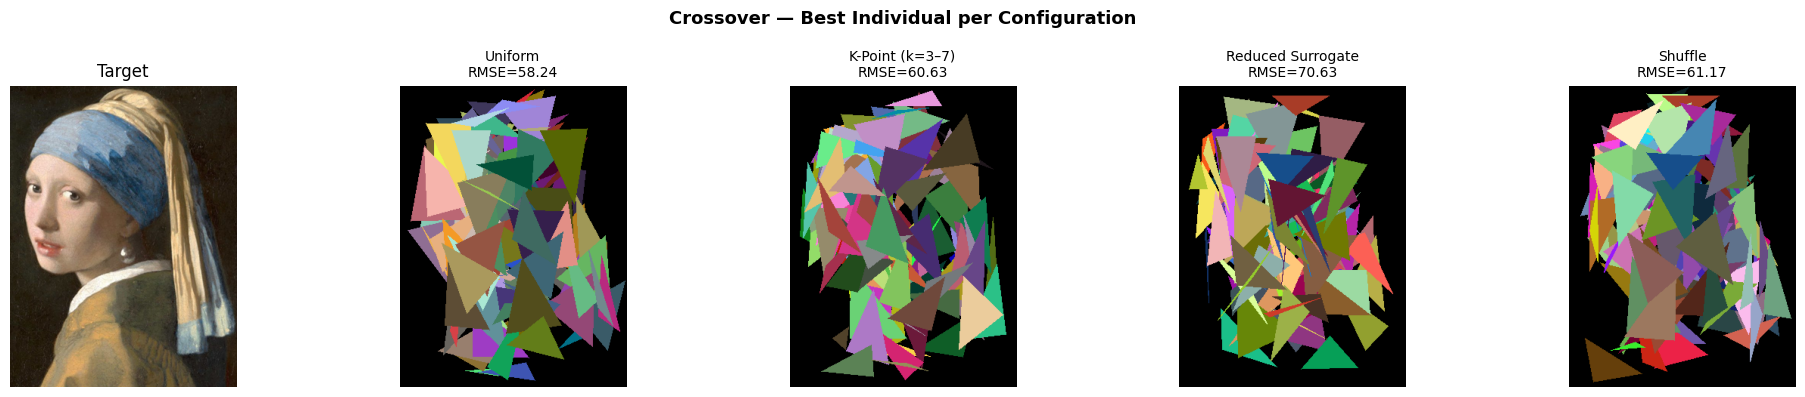

In [ ]:
# 4. Best individuals
plot_best_individuals(
    best_inds    = best_inds_xo,
    configs      = CROSSOVER_CONFIGS,
    target_img   = target_img,
    title_prefix = "Crossover",
)

Try **Adaptive Crossover** in which the type of crossover will change with the generations.

In [ ]:
# ADAPTIVE CROSSOVER â€” Standalone Run
# Uniform (0â€“50%) -> K-Point (50â€“85%) -> Reduced Surrogate (85â€“100%)

all_results_adp_xo, all_curves_adp_xo, best_ind_adp_xo = run_single_experiment(
    target_array= target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    xo_fn=adaptive_crossover_schedule,
    mut_fn=adaptive_mutation_schedule,  # best from Loop 1 CHANGE IF IT CHANGES
)

all_results_adp_xo


  Adaptive Crossover â€” Run 1/2
  Gen  500/5000 | RMSE: 40.2986 | op: Uniform | 503.2s
  Gen 1000/5000 | RMSE: 35.2423 | op: Uniform | 1092.9s
  Gen 1500/5000 | RMSE: 33.3721 | op: K-Point | 1551.8s
  Gen 2000/5000 | RMSE: 32.2769 | op: K-Point | 1998.7s
  Gen 2500/5000 | RMSE: 31.7203 | op: K-Point | 2438.7s
  Gen 3000/5000 | RMSE: 31.2356 | op: K-Point | 2867.2s
  Gen 3500/5000 | RMSE: 30.9834 | op: Red.Surrogate | 3304.2s
  Gen 4000/5000 | RMSE: 30.6699 | op: Red.Surrogate | 3747.2s
  Gen 4500/5000 | RMSE: 30.5175 | op: Red.Surrogate | 4296.7s
  Gen 5000/5000 | RMSE: 30.3796 | op: Red.Surrogate | 4940.9s
  â†’ Final RMSE: 30.3796

  Adaptive Crossover â€” Run 2/2
  Gen  500/5000 | RMSE: 42.8427 | op: Uniform | 595.5s
  Gen 1000/5000 | RMSE: 37.2163 | op: Uniform | 1012.6s
  Gen 1500/5000 | RMSE: 34.9945 | op: K-Point | 1440.0s
  Gen 2000/5000 | RMSE: 33.6309 | op: K-Point | 1916.8s
  Gen 2500/5000 | RMSE: 32.7860 | op: K-Point | 2353.7s
  Gen 3000/5000 | RMSE: 32.1151 | op: K-Poin

In [ ]:
# 1. Compare adaptive crossover vs best from Loop 2
# Replace "uniform" with whichever crossover won in compare_all_configs
avg_best_xo, avg_adaptive_xo, p_val_xo, significant_xo = compare_two_experiments(
    results_a = [r for r in all_results_xo if r["crossover_type"] == "Uniform"],
    curves_a  = all_curves_xo["Uniform"],
    label_a   = "Uniform",
    results_b = all_results_adp_xo,
    curves_b  = all_curves_adp_xo,
    label_b   = "Adaptive (Uniform â†’ K-Point â†’ Reduced Surrogate)",
)

In [ ]:
# 2. Plot convergence comparison
all_curves_xo_comparison = {
    "Uniform" : all_curves_xo["Uniform"],
    "Adaptive": all_curves_adp_xo,
}
all_results_xo_comparison = (
    [r for r in all_results_xo if r["crossover_type"] == "Uniform"] +
    [{"crossover_type": "Adaptive", **r} for r in all_results_adp_xo]
)
df_xo_comparison = pd.DataFrame(all_results_xo_comparison)

COMPARISON_XO_CONFIGS = [
    {"name": "Uniform",  "fn": uniform_crossover},
    {"name": "Adaptive", "fn": adaptive_crossover_schedule},
]

plot_experiment_summary(
    all_curves   = all_curves_xo_comparison,
    df           = df_xo_comparison,
    configs      = COMPARISON_XO_CONFIGS,
    config_key   = "crossover_type",
    title_prefix = "Uniform vs Adaptive Crossover",
)

In [ ]:
# 3. Best individual
plot_best_individuals(
    best_inds    = best_ind_adp_xo,
    configs      = None,
    target_img   = target_img,
    title_prefix = "Adaptive Crossover (Uniform â†’ K-Point â†’ Reduced Surrogate)",
)

!!!! O cÃ³digo a seguir faz um grÃ¡fico que nÃ£o sei se devemos manter

In [ ]:
gens     = np.arange(1, MAX_GENS + 1)
curves   = np.array(all_curves_adp_xo)
mean     = curves.mean(axis=0)
std      = curves.std(axis=0)
eb_every = max(1, MAX_GENS // 20)
eb_idx   = np.arange(0, MAX_GENS, eb_every)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 â€” Convergence curve (mean Â± std error bars) + individual runs
ax = axes[0]
for i, curve in enumerate(all_curves_adp_xo):
    ax.plot(gens, curve, alpha=0.3, linewidth=1, color="#9C27B0")
ax.plot(gens, mean, color="#9C27B0", linewidth=2.5, label="Mean")
ax.errorbar(
    gens[eb_idx], mean[eb_idx], yerr=std[eb_idx],
    fmt="none", ecolor="#9C27B0", elinewidth=1.2,
    capsize=4, capthick=1.2, alpha=0.8,
)
ax.axvline(MAX_GENS * 0.5,  color="gray", linestyle="--", linewidth=1, label="â†’ K-Point")
ax.axvline(MAX_GENS * 0.85, color="gray", linestyle=":",  linewidth=1, label="â†’ Red. Surrogate")
ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Avg Best Fitness (RMSE)", fontsize=12)
ax.set_title("Adaptive Crossover â€” Convergence\n(mean Â± std)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2 â€” Best individual
ax = axes[1]
ax.imshow(best_ind_adp_xo.render())
ax.set_title(f"Best Result\nRMSE={best_ind_adp_xo.fitness():.2f}", fontsize=12)
ax.axis("off")

fig.suptitle("Adaptive Crossover (Uniform â†’ K-Point â†’ Reduced Surrogate)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## **7. Limit Triangle Sizes** <a id="7"></a>

Constrain each triangle's bounding-box span to `MAX_TRIANGLE_SIZE` in normalised coordinates. Triangles that span the whole canvas hide the rest of the genome through alpha-blending and waste the limited 100-triangle budget, while very small triangles forfeit colour spread. We compare three settings of `MAX_TRIANGLE_SIZE` against the unconstrained baseline.


In [ ]:
# AUTOGEN_CIFO_SECTIONS_V1
# Section 7 size limit sweep.
# We monkey-patch solution.MAX_TRIANGLE_SIZE for each cell of the sweep,
# rebuild the initial population so the new constraint is enforced at
# construction, and run a short GA. Times are kept modest (500 gens, 300
# individuals, 3 runs) so the sweep is tractable on a single machine.

POP_SIZE_S7 = 300
MAX_GENS_S7 = 500
XO_PROB_S7  = 0.9
MUT_PROB_S7 = 0.05
N_RUNS_S7   = 30
SIZE_LIMITS = [1.00, 0.40, 0.25, 0.15]   # 1.00 = unconstrained baseline

In [ ]:
size_results = {}
size_curves  = {}
size_best    = {}

for size_limit in SIZE_LIMITS:
    print(f"\n=== MAX_TRIANGLE_SIZE = {size_limit:.2f} ===")

    all_results, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S7,
        max_gens            = MAX_GENS_S7,
        pop_size            = POP_SIZE_S7,
        seed                = SEED,
        xo_prob             = XO_PROB_S7,
        mut_prob            = MUT_PROB_S7,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = adaptive_mutation_schedule,
        individual_kwargs   = {"max_triangle_size": size_limit},
    )
    size_curves[size_limit]  = curves       # (N_RUNS, MAX_GENS)
    size_best[size_limit]    = best         # best Individual across all runs
    size_results[size_limit] = all_results  # all runs results

In [ ]:
# Summary table
df_s7 = pd.DataFrame([
    {"max_triangle_size": str(s), **r}
    for s in SIZE_LIMITS
    for r in size_results[s]
])

# Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = {str(s): size_curves[s] for s in SIZE_LIMITS},
    df           = df_s7,
    configs      = [{"name": str(s)} for s in SIZE_LIMITS],
    config_key   = "max_triangle_size",
    title_prefix = "Size Limits",
)

In [ ]:
# Statistical comparison â€” Kruskal-Wallis + Mann-Whitney + Bonferroni
summary_s7, avg_curves_s7 = compare_all_configs(
    all_results = df_s7.to_dict("records"),
    all_curves  = {str(s): size_curves[s] for s in SIZE_LIMITS},
    config_key  = "max_triangle_size",
)

In [ ]:
# Best individuals per config
plot_best_individuals(
    best_inds    = {str(s): size_best[s] for s in SIZE_LIMITS},
    configs      = [{"name": str(s)} for s in SIZE_LIMITS],
    target_img   = target_img,
    title_prefix = "Triangle Size Limit",
)

## **8. Limit Alpha values** <a id="8"></a>

Clip each triangle's alpha channel to a window `[ALPHA_MIN, ALPHA_MAX]`. `alpha=0` makes the triangle invisible -- a wasted gene block -- while `alpha=1` makes it fully opaque and hides everything below it, defeating the alpha-blending stacking that the rendered painting relies on. We compare three windows against the unconstrained `[0, 1]` baseline.


In [ ]:
# Section 8 -- alpha window sweep. Same protocol as Section 7.
POP_SIZE_S8 = 300
MAX_GENS_S8 = 500
XO_PROB_S8  = 0.9
MUT_PROB_S8 = 0.05
N_RUNS_S8   = 30
ALPHA_WINDOWS = [(0.00, 1.00), (0.20, 0.90), (0.30, 0.80), (0.50, 0.70)]

In [ ]:
alpha_results = {}
alpha_curves  = {}
alpha_best    = {}

for alpha_min, alpha_max in ALPHA_WINDOWS:
    key = f"({alpha_min:.2f}, {alpha_max:.2f})"
    print(f"\n=== ALPHA_WINDOW = {key} ===")

    all_results, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S8,
        max_gens            = MAX_GENS_S8,
        pop_size            = POP_SIZE_S8,
        seed                = SEED,
        xo_prob             = XO_PROB_S8,
        mut_prob            = MUT_PROB_S8,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = adaptive_mutation_schedule,
        individual_kwargs   = {"alpha_min": alpha_min, "alpha_max": alpha_max},
    )
    alpha_curves[key]  = curves
    alpha_best[key]    = best
    alpha_results[key] = all_results

In [ ]:
# Summary table
df_s8 = pd.DataFrame([
    {"alpha_window": key, **r}
    for key, results in alpha_results.items()
    for r in results
])

# Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = alpha_curves,
    df           = df_s8,
    configs      = [{"name": k} for k in alpha_curves.keys()],
    config_key   = "alpha_window",
    title_prefix = "Alpha Window",
)

In [ ]:
# Statistical comparison
summary_s8, avg_curves_s8 = compare_all_configs(
    all_results = df_s8.to_dict("records"),
    all_curves  = alpha_curves,
    config_key  = "alpha_window",
)

In [ ]:
# Best individuals per config
plot_best_individuals(
    best_inds    = alpha_best,
    configs      = [{"name": k} for k in alpha_curves.keys()],
    target_img   = target_img,
    title_prefix = "Alpha Window",
)

## **9. Probabilities Tests** <a id="9"></a>

Test different values for the probabilities of crossover and mutation

In [ ]:
# 6. HYPERPARAMETER SEARCH â€” Mutation & Crossover Probabilities
# Loop 2 â€” Grid search over mut_prob x xo_prob
# Mutation type and crossover type fixed: triangle_mutation_vcf + triangle_crossover (winners from Loops 1 & 2)

# CONFIG
POP_SIZE  = 200
MAX_GENS  = 300
N_RUNS    = 30
ELITISM   = True

MUT_PROBS = [0.01, 0.05, 0.15]
XO_PROBS  = [0.7, 0.8, 0.9, 0.95]

# Total combinations
PROB_CONFIGS = list(itertools.product(MUT_PROBS, XO_PROBS))
print(f"Total configurations: {len(PROB_CONFIGS)}  |  Total runs: {len(PROB_CONFIGS) * N_RUNS}")

Total configurations: 12  |  Total runs: 60


In [ ]:
all_results_prob, all_curves_prob, best_inds_prob = run_experiment(
    configs              = PROB_CONFIGS,
    target_array         = target_array,
    n_runs               = N_RUNS,
    max_gens             = MAX_GENS,
    pop_size             = POP_SIZE,
    seed                 = SEED,
    xo_prob              = None,   # set per config
    mut_prob             = None,   # set per config
    elitism              = ELITISM,
    selection_algorithm  = tournament_selection,
    fixed_xo_fn          = triangle_crossover,
    fixed_mut_fn         = adaptive_mutation_schedule,
    config_key           = "config",
)

In [ ]:
# Summary table â€” grouped by mut_prob and xo_prob
df_prob = pd.DataFrame(all_results_prob)
df_prob["mut_prob"] = df_prob["config"].apply(lambda x: x[0])
df_prob["xo_prob"]  = df_prob["config"].apply(lambda x: x[1])

summary_prob = (
    df_prob.groupby(["mut_prob", "xo_prob"])[["best_fitness", "time_seconds"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "avg", "std": "std", "min": "best", "max": "worst"})
    .sort_values(("best_fitness", "avg"))
)

print("\n--- SUMMARY (sorted by avg fitness) ---")
print(summary_prob.to_string(index=False))

In [ ]:
# Statistical comparison across all configs
summary_stats, avg_curves_prob = compare_all_configs(
    all_results = all_results_prob,
    all_curves  = all_curves_prob,
    config_key  = "config",
)

In [ ]:
# Heatmap â€” mantÃ©m o que tinhas, Ã© uma visualizaÃ§Ã£o Ãºtil para o grid search
pivot = summary_prob.pivot(
    index   = ("mut_prob", ""),
    columns = ("xo_prob", ""),
    values  = ("best_fitness", "avg"),
)

In [ ]:
# Plot convergence curves grouped by xo_prob (um subplot por xo_prob)
colors_mut = {0.01: "#4CAF50", 0.05: "#2196F3", 0.15: "#F44336"}
gens       = np.arange(1, MAX_GENS + 1)
eb_every   = max(1, MAX_GENS // 20)
eb_idx     = np.arange(0, MAX_GENS, eb_every)

fig, axes = plt.subplots(1, len(XO_PROBS), figsize=(15, 5), sharey=True)

for ax, xo_prob in zip(axes, XO_PROBS):
    for mut_prob in MUT_PROBS:
        curves = np.array(all_curves_prob[(mut_prob, xo_prob)])
        mean   = curves.mean(axis=0)
        std    = curves.std(axis=0)
        color  = colors_mut[mut_prob]
        ax.plot(gens, mean, label=f"mut={mut_prob}", color=color, linewidth=2)
        ax.errorbar(
            gens[eb_idx], mean[eb_idx], yerr=std[eb_idx],
            fmt="none", ecolor=color, elinewidth=1.2,
            capsize=4, capthick=1.2, alpha=0.8,
        )
    ax.set_title(f"xo_prob = {xo_prob}", fontsize=12)
    ax.set_xlabel("Generation", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

axes[0].set_ylabel("Avg Best Fitness (RMSE)", fontsize=11)
fig.suptitle("Convergence by xo_prob (mean Â± std)", fontsize=13)
plt.tight_layout()
plt.show()

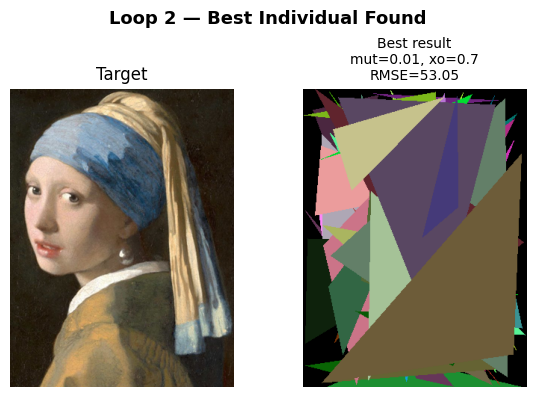

In [ ]:
# Find the best config across all probability combinations
best_config = min(all_results_prob, key=lambda x: x["best_fitness"])["config"]

# Plot best individual â€” single mode
plot_best_individuals(
    best_inds    = best_inds_prob[best_config],
    configs      = None,
    target_img   = target_img,
    title_prefix = f"Best Probability Configuration\nmut={best_config[0]}, xo={best_config[1]}",
)

## **10. Increase Population size and the number of generations** <a id="10"></a>

We try to improve fitness by increasing the size of the Population and the Number of generations when running the genetic algorithm. We use the best crossover and mutation functions as well as the 2 best probability combinations.

Having identified the best configuration through statistically validated experiments, we performed a single extended run with a larger population and more generations to maximize the quality of the final result.

### **XO_PROB   = 0.9** e **MUT_PROB  = 0.01**

In [ ]:
# 7. Final Run
# Best hyperparameters from Loop 1 & 2:
#   - Mutation type : triangle_mutation_vcf
#   - mut_prob      : 0.05
#   - xo_prob       : 1.0
# Population: 50 | Generations: 500 | Elitism: True
# Saves convergence curve + evolution snapshots every 100 generations

# CONFIG
POP_SIZE  = 500
MAX_GENS  = 15000
XO_PROB   = 0.9
MUT_PROB  = 0.01
ELITISM   = True


In [ ]:
# Final run with best hyperparameters
all_results_1, all_curves_1, best_ind_1 = run_single_experiment(
    target_array        = target_array,
    n_runs              = 1,      # single long run
    max_gens            = MAX_GENS,
    pop_size            = POP_SIZE,
    seed                = SEED,
    xo_prob             = XO_PROB,
    mut_prob            = MUT_PROB,
    elitism             = ELITISM,
    selection_algorithm = tournament_selection,
    xo_fn               = triangle_crossover,
    mut_fn              = adaptive_mutation_schedule,
)

In [ ]:
df_final = pd.DataFrame(all_results_1)
print("\n--- Final Run 1 Results ---")
print(df_final[["best_fitness", "time_seconds"]].to_string(index=False))

In [ ]:
# Convergence curve â€” single run so no mean/std, just the raw curve
plot_convergence_curve(
    fitness_curve  = all_curves_1[0],   # all_curves_1 is a list of 1 curve
    baseline_rmse  = baseline_rmse,
    MAX_GENS       = MAX_GENS,
)

In [ ]:
# Best individual
plot_best_individuals(
    best_inds    = best_ind_1,
    configs      = None,
    target_img   = target_img,
    title_prefix = "Final Run â€” Best Individual",
)

### **XO_PROB   = 0.7** and **MUT_PROB  = 0.05**

In [ ]:
# 7. Final Run
# Best hyperparameters from Loop 1 & 2:
#   - Mutation type : triangle_mutation_vcf
#   - mut_prob      : 0.05
#   - xo_prob       : 1.0
# Population: 50 | Generations: 500 | Elitism: True
# Saves convergence curve + evolution snapshots every 100 generations

# CONFIG
POP_SIZE  = 500
MAX_GENS  = 15000
XO_PROB   = 0.7
MUT_PROB  = 0.01
ELITISM   = True

In [ ]:
# Final run 2 â€” second best probability combination
all_results_2, all_curves_2, best_ind_2 = run_single_experiment(
    target_array        = target_array,
    n_runs              = 1,
    max_gens            = MAX_GENS,
    pop_size            = POP_SIZE,
    seed                = SEED,
    xo_prob             = XO_PROB,
    mut_prob            = MUT_PROB,
    elitism             = ELITISM,
    selection_algorithm = tournament_selection,
    xo_fn               = triangle_crossover,
    mut_fn              = adaptive_mutation_schedule,
)

In [ ]:
print("\n--- Final Run 2 Results ---")
print(f"  Best RMSE : {all_results_2[0]['best_fitness']:.4f}")
print(f"  Time      : {all_results_2[0]['time_seconds']:.2f}s")

In [ ]:
# Convergence curve
plot_convergence_curve(
    fitness_curve = all_curves_2[0],
    baseline_rmse = baseline_rmse,
    MAX_GENS      = MAX_GENS,
)

In [ ]:
# Best individual
plot_best_individuals(
    best_inds    = best_ind_2,
    configs      = None,
    target_img   = target_img,
    title_prefix = "Final Run 2 â€” Best Individual",
)

## **11. Try to Increase Diversity** <a id="11"></a>

Two anti-convergence mechanisms compared head-to-head against the static-mutation baseline:

- **Adaptive mutation (Rechenberg 1/5 success rule, 1973).** Track the fraction of offspring that beat their parents over a 10-generation window and scale `mut_prob` up if more than 1/5 succeed, down otherwise.
- **Diversity injection.** When the std of fitness drops below 50% of its initial value, replace the worst 20% of the population with fresh random individuals.


In [ ]:
POP_SIZE_S11 = 300
MAX_GENS_S11 = 500
XO_PROB_S11  = 0.9
MUT_PROB_S11 = 0.05
N_RUNS_S11   = 30

DIVERSITY_CONFIGS = {
    "baseline":             dict(),
    "adaptive mutation":    dict(adaptive_mutation=True),
    "diversity injection":  dict(diversity_injection=True),
    "adaptive + injection": dict(adaptive_mutation=True, diversity_injection=True),
}

In [ ]:
div_results = {}
div_curves  = {}
div_best    = {}

for name, ga_kwargs in DIVERSITY_CONFIGS.items():
    print(f"\n=== {name} ===")

    all_results, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S11,
        max_gens            = MAX_GENS_S11,
        pop_size            = POP_SIZE_S11,
        seed                = SEED,
        xo_prob             = XO_PROB_S11,
        mut_prob            = MUT_PROB_S11,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = adaptive_mutation_schedule,
        **ga_kwargs,
    )
    div_results[name] = all_results  # all N_RUNS results â€” not just best.fitness()
    div_curves[name]  = curves
    div_best[name]    = best

In [ ]:
# Summary table
df_div = pd.DataFrame([
    {"diversity_config": name, **r}
    for name, results in div_results.items()
    for r in results
])

In [ ]:
# Plot convergence + boxplot
plot_experiment_summary(
    all_curves   = div_curves,
    df           = df_div,
    configs      = [{"name": n} for n in div_results.keys()],
    config_key   = "diversity_config",
    title_prefix = "Diversity Mechanisms",
)

In [ ]:
# Statistical comparison
summary_div, avg_curves_div = compare_all_configs(
    all_results = df_div.to_dict("records"),
    all_curves  = div_curves,
    config_key  = "diversity_config",
)

In [ ]:
# Best individuals
plot_best_individuals(
    best_inds    = div_best,
    configs      = [{"name": n} for n in div_results.keys()],
    target_img   = target_img,
    title_prefix = "Diversity Mechanisms",
)

## **12. Challenge 1 -- Perceptual Fitness (CIEDE2000)** <a id="12"></a>

Raw RGB RMSE weighs every channel error equally, but the human visual system is more sensitive to luminance shifts than to small chroma changes. CIE Lab is approximately perceptually uniform, and **CIEDE2000** (Sharma, Wu & Dalal 2005) corrects the residual non-uniformities of Lab around the blue and grey regions.

We re-run the GA with `fitness_metric="ciede2000"`. Note that the two metrics are on different scales -- we compare them by re-evaluating the *same* CIEDE2000 winner under the RMSE metric (and vice-versa) and by looking at the rendered images side by side.


In [ ]:
# Section 12 -- Challenge 1 (CIEDE2000 perceptual fitness).
POP_SIZE_S12 = 300
MAX_GENS_S12 = 500
XO_PROB_S12  = 0.9
MUT_PROB_S12 = 0.05
N_RUNS_S12   = 30

In [ ]:
challenge_results = {}
challenge_curves  = {}
challenge_best    = {}

for metric in ["rmse", "ciede2000"]:
    print(f"\n=== {metric.upper()} ===")

    all_results, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S12,
        max_gens            = MAX_GENS_S12,
        pop_size            = POP_SIZE_S12,
        seed                = SEED,
        xo_prob             = XO_PROB_S12,
        mut_prob            = MUT_PROB_S12,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = adaptive_mutation_schedule,
        individual_kwargs   = {"fitness_metric": metric},
    )
    challenge_results[metric] = all_results  # all runs â€” not just best.fitness()
    challenge_curves[metric]  = curves
    challenge_best[metric]    = best

In [ ]:
# Summary table
df_challenge = pd.DataFrame([
    {"fitness_metric": metric, **r}
    for metric, results in challenge_results.items()
    for r in results
])

In [ ]:
# Plot convergence
plot_experiment_summary(
    all_curves   = challenge_curves,
    df           = df_challenge,
    configs      = [{"name": m} for m in challenge_results.keys()],
    config_key   = "fitness_metric",
    title_prefix = "Fitness Metric (RMSE vs CIEDE2000)",
)

In [ ]:
# Statistical comparison â€” Wilcoxon aqui faz sentido porque sÃ£o sÃ³ 2 configs
avg_rmse, avg_ciede, p_val, significant = compare_two_experiments(
    results_a = [r for r in df_challenge.to_dict("records") if r["fitness_metric"] == "rmse"],
    curves_a  = challenge_curves["rmse"],
    label_a   = "RMSE",
    results_b = [r for r in df_challenge.to_dict("records") if r["fitness_metric"] == "ciede2000"],
    curves_b  = challenge_curves["ciede2000"],
    label_b   = "CIEDE2000",
)

In [ ]:
# Cross-evaluation â€” mantÃ©m exatamente o que tinhas, estÃ¡ correto
rendered_rmse  = np.asarray(challenge_best["rmse"].render(),      dtype=np.float32)
rendered_ciede = np.asarray(challenge_best["ciede2000"].render(), dtype=np.float32)
target_lab     = rgb_to_lab(target_array)

rmse_of_rmse_winner   = float(np.sqrt(np.mean((rendered_rmse  - target_array) ** 2)))
rmse_of_ciede_winner  = float(np.sqrt(np.mean((rendered_ciede - target_array) ** 2)))
ciede_of_rmse_winner  = float(np.mean(ciede2000(rgb_to_lab(rendered_rmse),  target_lab)))
ciede_of_ciede_winner = float(np.mean(ciede2000(rgb_to_lab(rendered_ciede), target_lab)))

print("\n--- Cross-metric comparison ---")
print(f"  RMSE winner    -> RMSE {rmse_of_rmse_winner:.2f}  | CIEDE2000 {ciede_of_rmse_winner:.2f}")
print(f"  CIEDE winner   -> RMSE {rmse_of_ciede_winner:.2f} | CIEDE2000 {ciede_of_ciede_winner:.2f}")

# Visual comparison â€” mantÃ©m o que tinhas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_img)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(challenge_best["rmse"].render())
axes[1].set_title(f"RMSE-optimised\nRMSE={rmse_of_rmse_winner:.1f} | dE={ciede_of_rmse_winner:.1f}")
axes[1].axis("off")

axes[2].imshow(challenge_best["ciede2000"].render())
axes[2].set_title(f"CIEDE2000-optimised\nRMSE={rmse_of_ciede_winner:.1f} | dE={ciede_of_ciede_winner:.1f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()